Proyecto Final — Text Mining & Image Recognition:


\
\
Amós Nehemías Illú Chapetón - 12182346
\
Kevin Alejandro Reyes Alvarez - 25001516
\
Íñigo Alvarado Guirola - 19000305

Problema 1: Análisis de usuarios populares en Twitter mediante Word Clouds

In [1]:
!pip install nltk wordcloud contractions
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


import nltk
import contractions


from wordcloud import WordCloud


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.8/114.8 kB 9.1 MB/s eta 0:00:00


**Cargar el dataset**


In [2]:
# Definir los nombres de las columnas según la estructura
# del dataset de tweets.

columnas = [
    'sentiment',
    'tweet_id',
    'timestamp',
    'query',
    'username',
    'content'
]



df = pd.read_csv(
    'tw_source.csv',
    encoding='latin1',
    header=None,
    names=columnas
)

# Mostramos las primeras cinco filas para verificar
# que la información se haya cargado correctamente.

df.head()

,sentiment,tweet_id,timestamp,query,username,content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
print(f"Cantidad de tweets: {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]}")

# Mostramos información general sobre los tipos de datos y los valores no nulos de cada columna.

df.info()

Cantidad de tweets: 379,110
Cantidad de columnas: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379110 entries, 0 to 379109
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   sentiment  379110 non-null  int64 
 1   tweet_id   379110 non-null  int64 
 2   timestamp  379110 non-null  object
 3   query      379110 non-null  object
 4   username   379109 non-null  object
 5   content    379109 non-null  object
dtypes: int64(2), object(4)
memory usage: 17.4+ MB


**Identificación de los 3 usuarios más populares** \
\
Se analizarán los textos de los tweets para identificar los usuarios que son mencionados con mayor frecuencia.

Para realizar este proceso se utilizarán expresiones regulares, las cuales permiten detectar patrones específicos dentro de un texto. En este caso, se buscarán las menciones que comienzan con el símbolo @.

In [4]:
#Extraer las menciones utilizando expresiones regulares
# Definir una expresión regular para identificar menciones de usuarios dentro del contenido de cada tweet.
# El patrón @ seguido de letras, números o guion bajo


patron_menciones = r'@[A-Za-z0-9_]+'

# Aplicamos la expresión regular a todos los tweets.
# findall() devuelve una lista con todas las menciones


df['menciones'] = df['content'].astype(str).apply(
    lambda texto: re.findall(patron_menciones, texto)
)

# Mostramos algunos ejemplos para verificar
# que las menciones fueron extraídas correctamente.

df[['content', 'menciones']].head(10)

,content,menciones
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",[@switchfoot]
1,is upset that he can't update his Facebook by ...,[]
2,@Kenichan I dived many times for the ball. Man...,[@Kenichan]
3,my whole body feels itchy and like its on fire,[]
4,"@nationwideclass no, it's not behaving at all....",[@nationwideclass]
5,@Kwesidei not the whole crew,[@Kwesidei]
6,Need a hug,[]
7,@LOLTrish hey long time no see! Yes.. Rains a...,[@LOLTrish]
8,@Tatiana_K nope they didn't have it,[@Tatiana_K]
9,@twittera que me muera ?,[@twittera]


In [5]:
#Contabilizar las menciones de cada usuario
# Explode transforma cada lista de menciones en filas individuales.


menciones = df['menciones'].explode()

# Eliminar los valores nulos, ya que algunos tweets


menciones = menciones.dropna()

# Convertimos todas las menciones a minúsculas para evitar contabilizar como usuarios diferentes aquellos que solo
# cambian en el uso de mayúsculas y minúsculas.

menciones = menciones.str.lower()

# Contabilizamos la frecuencia de cada usuario mencionado.

conteo_usuarios = menciones.value_counts()

# Mostramos los 10 usuarios con mayor cantidad de menciones.

conteo_usuarios.head(10)

,count
menciones,
@tommcfly,884
@mileycyrus,853
@ddlovato,482
@jonathanrknight,300
@mitchelmusso,271
@donniewahlberg,231
@jonasbrothers,224
@taylorswift13,211
@davidarchie,209


In [6]:
#Obtener los 3 usuarios más populares
# Seleccionar los tres usuarios que presentan la mayor cantidad de menciones en el dataset.

top_3_usuarios = conteo_usuarios.head(3)

# Mostrar los resultados.

print("Los 3 usuarios más populares son:\n")
print(top_3_usuarios)

Los 3 usuarios más populares son:

menciones
@tommcfly      884
@mileycyrus    853
@ddlovato      482
Name: count, dtype: int64


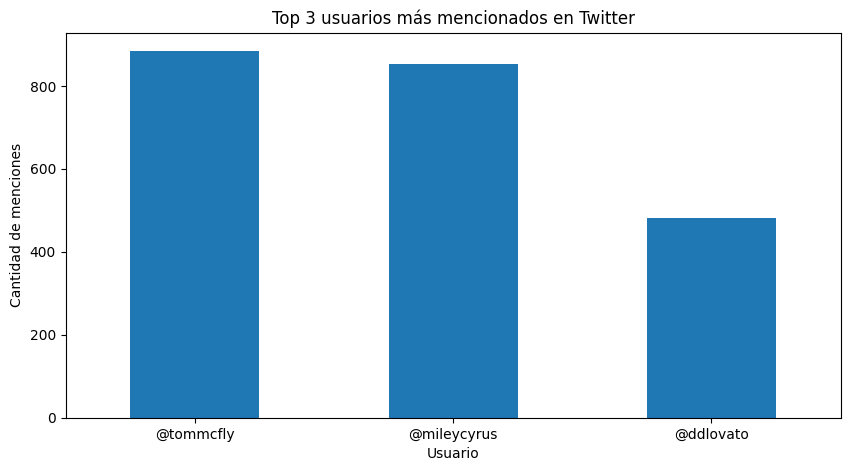

In [7]:
#Visualización de los resultados
# Creamos un gráfico de barras para visualizar la cantidad de menciones de los tres usuarios
# identificados anteriormente.

plt.figure(figsize=(10, 5))

top_3_usuarios.plot(kind='bar')

plt.title('Top 3 usuarios más mencionados en Twitter')
plt.xlabel('Usuario')
plt.ylabel('Cantidad de menciones')
plt.xticks(rotation=0)

plt.show()

**Creación de los 3 corpus individuales**
\
\
Una vez identificados los tres usuarios más mencionados, se procederá a crear un corpus independiente para cada uno.

In [8]:
# Mostramos los tres usuarios más mencionados identificados
# durante el análisis anterior.

top_3_usuarios

,count
menciones,
@tommcfly,884
@mileycyrus,853
@ddlovato,482


In [9]:
# Calculamos la longitud de cada tweet contando la cantidad
# de caracteres que contiene su texto.


df['length'] = df['content'].astype(str).str.len()

# Verificamos el resultado mostrando el contenido
# y su longitud correspondiente.

df[['content', 'length']].head()

,content,length
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",115
1,is upset that he can't update his Facebook by ...,111
2,@Kenichan I dived many times for the ball. Man...,89
3,my whole body feels itchy and like its on fire,47
4,"@nationwideclass no, it's not behaving at all....",111


In [11]:
#Filtrar los tweets de cada usuario
# El método replace() elimina el símbolo @ para que


usuario_1 = top_3_usuarios.index[0].replace('@', '')
usuario_2 = top_3_usuarios.index[1].replace('@', '')
usuario_3 = top_3_usuarios.index[2].replace('@', '')

# Filtramos los tweets que contienen una mención a cada uno de los tres usuarios.


corpus_usuario_1 = df[
    df['content'].str.contains(
        rf'@{re.escape(usuario_1)}\b',
        case=False,
        na=False,
        regex=True
    )
].copy()

corpus_usuario_2 = df[
    df['content'].str.contains(
        rf'@{re.escape(usuario_2)}\b',
        case=False,
        na=False,
        regex=True
    )
].copy()

corpus_usuario_3 = df[
    df['content'].str.contains(
        rf'@{re.escape(usuario_3)}\b',
        case=False,
        na=False,
        regex=True
    )
].copy()

# Mostramos la cantidad de tweets que contiene cada corpus.

print(f"Corpus de @{usuario_1}: {len(corpus_usuario_1):,} tweets")
print(f"Corpus de @{usuario_2}: {len(corpus_usuario_2):,} tweets")
print(f"Corpus de @{usuario_3}: {len(corpus_usuario_3):,} tweets")

Corpus de @tommcfly: 883 tweets
Corpus de @mileycyrus: 849 tweets
Corpus de @ddlovato: 477 tweets


In [13]:
#Seleccionar las columnas solicitadas
# Definimos las columnas que formarán parte de cada corpus.


columnas_corpus = [
    'content',
    'tweet_id',
    'timestamp',
    'length'
]

# Seleccionamos únicamente las columnas necesarias
# para cada uno de los tres corpus.

corpus_usuario_1 = corpus_usuario_1[columnas_corpus].copy()
corpus_usuario_2 = corpus_usuario_2[columnas_corpus].copy()
corpus_usuario_3 = corpus_usuario_3[columnas_corpus].copy()

# Mostramos una vista previa del primer corpus.

corpus_usuario_1.head()

,content,tweet_id,timestamp,length
1690,@tommcfly hey saw u guys play @ pushover..didn...,1468210813,Tue Apr 07 00:19:09 PDT 2009,138
1789,@tommcfly Good morning Tom! Why can't I send y...,1468233211,Tue Apr 07 00:26:52 PDT 2009,131
2514,@tommcfly did you know that johnsons baby use ...,1468391638,Tue Apr 07 01:23:07 PDT 2009,96
3029,"@dougiemcfly @tommcfly good morning guys, how ...",1468502040,Tue Apr 07 02:03:41 PDT 2009,108
3524,"@tommcfly hey, no chance of adding brighton or...",1468618787,Tue Apr 07 02:46:02 PDT 2009,131


In [14]:
#Verificar la estructura de los corpus
# Revisar la estructura de los tres corpus creados
# para confirmar que contienen las columnas solicitadas.

print("Estructura del corpus 1:")
display(corpus_usuario_1.head())

print("\nEstructura del corpus 2:")
display(corpus_usuario_2.head())

print("\nEstructura del corpus 3:")
display(corpus_usuario_3.head())

Estructura del corpus 1:


,content,tweet_id,timestamp,length
1690,@tommcfly hey saw u guys play @ pushover..didn...,1468210813,Tue Apr 07 00:19:09 PDT 2009,138
1789,@tommcfly Good morning Tom! Why can't I send y...,1468233211,Tue Apr 07 00:26:52 PDT 2009,131
2514,@tommcfly did you know that johnsons baby use ...,1468391638,Tue Apr 07 01:23:07 PDT 2009,96
3029,"@dougiemcfly @tommcfly good morning guys, how ...",1468502040,Tue Apr 07 02:03:41 PDT 2009,108
3524,"@tommcfly hey, no chance of adding brighton or...",1468618787,Tue Apr 07 02:46:02 PDT 2009,131



Estructura del corpus 2:


,content,tweet_id,timestamp,length
1021,@mileycyrus hahaha dont be like that one time ...,1468063101,Mon Apr 06 23:30:57 PDT 2009,107
2014,"@mileycyrus i have the same problem, but it's ...",1468286517,Tue Apr 07 00:45:20 PDT 2009,137
2073,@mileycyrus I guess counting sheep didn't work...,1468297110,Tue Apr 07 00:49:07 PDT 2009,72
2080,@mileycyrus I would too if it meant spending a...,1468298918,Tue Apr 07 00:49:44 PDT 2009,100
2156,@mileycyrus AWWW u seriously have the cutest d...,1468318249,Tue Apr 07 00:56:41 PDT 2009,112



Estructura del corpus 3:


,content,tweet_id,timestamp,length
460,@ddlovato @David_Henrie ummmmm i cant find it.,1467929230,Mon Apr 06 22:51:34 PDT 2009,47
573,@ddlovato Do you hate us?? Please don't,1467953367,Mon Apr 06 22:58:30 PDT 2009,40
7032,@ddlovato Wish that i could see it.. Thats th...,1469661950,Tue Apr 07 07:02:58 PDT 2009,96
7089,"@ddlovato hey demi, wen are you and selena gon...",1469674492,Tue Apr 07 07:05:11 PDT 2009,79
8611,@ddlovato ahhhh i wish i could go to the dalla...,1548280868,Fri Apr 17 20:31:31 PDT 2009,85


In [15]:
print(f"Corpus de @{usuario_1}: {len(corpus_usuario_1):,} tweets")
print(f"Corpus de @{usuario_2}: {len(corpus_usuario_2):,} tweets")
print(f"Corpus de @{usuario_3}: {len(corpus_usuario_3):,} tweets")

Corpus de @tommcfly: 883 tweets
Corpus de @mileycyrus: 849 tweets
Corpus de @ddlovato: 477 tweets


**Validación y análisis de los metadatos**
\
\
Después de crear los tres corpus, se realizará una validación de su estructura para comprobar que contienen los campos.
También se revisará la existencia de valores nulos y se calcularán estadísticas descriptivas sobre la longitud de los tweets.

In [16]:
# Definimos los nombres de las columnas que esperamos
# encontrar en cada uno de los corpus.

columnas_esperadas = [
    'content',
    'tweet_id',
    'timestamp',
    'length'
]

# Verificamos que todos los corpus contengan
# las columnas requeridas.

print("¿Las columnas del corpus 1 son correctas?:",
      list(corpus_usuario_1.columns) == columnas_esperadas)

print("¿Las columnas del corpus 2 son correctas?:",
      list(corpus_usuario_2.columns) == columnas_esperadas)

print("¿Las columnas del corpus 3 son correctas?:",
      list(corpus_usuario_3.columns) == columnas_esperadas)

¿Las columnas del corpus 1 son correctas?: True
¿Las columnas del corpus 2 son correctas?: True
¿Las columnas del corpus 3 son correctas?: True


In [17]:
#Revisar valores nulos
# Revisamos la cantidad de valores nulos en cada columna
# de los tres corpus.

print("Valores nulos — Corpus 1:")
display(corpus_usuario_1.isnull().sum())

print("Valores nulos — Corpus 2:")
display(corpus_usuario_2.isnull().sum())

print("Valores nulos — Corpus 3:")
display(corpus_usuario_3.isnull().sum())

Valores nulos — Corpus 1:


,0
content,0
tweet_id,0
timestamp,0
length,0


Valores nulos — Corpus 2:


,0
content,0
tweet_id,0
timestamp,0
length,0


Valores nulos — Corpus 3:


,0
content,0
tweet_id,0
timestamp,0
length,0


In [18]:
#Estadísticas descriptivas de la longitud de los tweets
# Generamos estadísticas descriptivas sobre la longitud
# de los tweets en cada corpus.

print("Estadísticas de longitud — Corpus 1:")
display(corpus_usuario_1['length'].describe())

print("Estadísticas de longitud — Corpus 2:")
display(corpus_usuario_2['length'].describe())

print("Estadísticas de longitud — Corpus 3:")
display(corpus_usuario_3['length'].describe())

Estadísticas de longitud — Corpus 1:


,length
count,883.000000
mean,93.037373
std,35.664628
min,10.000000
25%,64.000000
50%,93.000000
75%,130.000000
max,201.000000


Estadísticas de longitud — Corpus 2:


,length
count,849.000000
mean,84.008245
std,35.572921
min,16.000000
25%,53.000000
50%,81.000000
75%,118.000000
max,156.000000


Estadísticas de longitud — Corpus 3:


,length
count,477.000000
mean,91.329140
std,33.987495
min,19.000000
25%,65.000000
50%,91.000000
75%,123.000000
max,148.000000


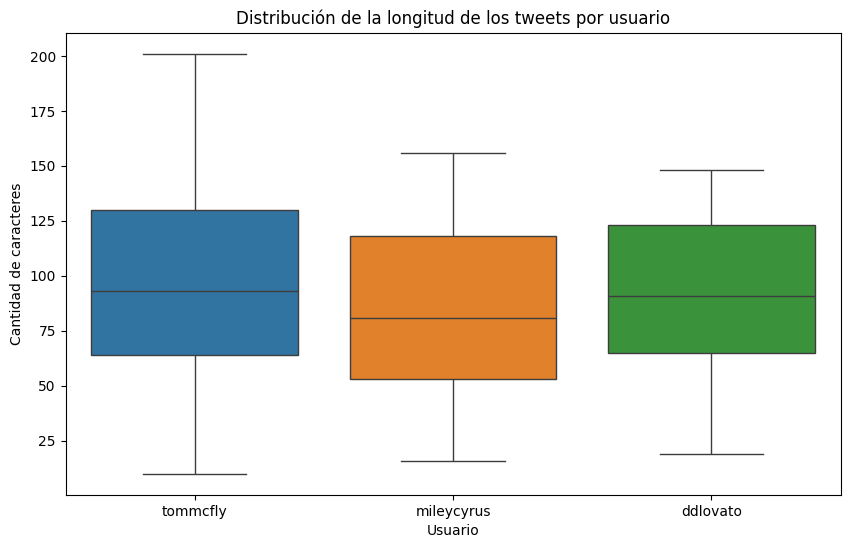

In [19]:
#Visualizar la distribución de longitudes
# Combinamos la información de longitud de los tres corpus
# para facilitar la comparación mediante un gráfico.

longitudes = pd.DataFrame({
    'tommcfly': corpus_usuario_1['length'],
    'mileycyrus': corpus_usuario_2['length'],
    'ddlovato': corpus_usuario_3['length']
})

# Generamos un gráfico de cajas para observar
# la distribución y posibles valores extremos.

plt.figure(figsize=(10, 6))

sns.boxplot(data=longitudes)

plt.title('Distribución de la longitud de los tweets por usuario')
plt.xlabel('Usuario')
plt.ylabel('Cantidad de caracteres')

plt.show()

**Limpieza y preprocesamiento de los tweets**
\
\
Eliminar elementos que no aportan valor al análisis de las palabras que rodean a cada usuario, como enlaces, menciones y caracteres especiales.

In [20]:
import string
import contractions

In [21]:
# Definimos una función para limpiar el contenido de los tweets.


def limpiar_texto(texto):

    # Convertimos el contenido a texto para evitar inconvenientes si existieran valores no textuales.
    texto = str(texto)

    # Expandimos contracciones en inglés.
    # Ejemplo: "don't" se convierte en "do not".
    texto = contractions.fix(texto)

    # Convertimos todo el texto a minúsculas.
    texto = texto.lower()

    # Eliminamos las URLs presentes en los tweets.
    texto = re.sub(r'https?://\S+|www\.\S+', '', texto)

    # Eliminamos las menciones de usuarios.

    texto = re.sub(r'@[a-z0-9_]+', '', texto)

    # Eliminamos la palabra RT cuando aparece como indicador de un retweet.
    texto = re.sub(r'\brt\b', '', texto)

    # Eliminamos los caracteres que no sean letras del alfabeto inglés o espacios.
    texto = re.sub(r'[^a-z\s]', ' ', texto)

    # Reemplazamos múltiples espacios por uno solo.
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

In [23]:
#Aplicar la limpieza a los tres corpus
# Aplicamos la función de limpieza a los tres corpus.


corpus_usuario_1['clean_content'] = (
    corpus_usuario_1['content'].apply(limpiar_texto)
)

corpus_usuario_2['clean_content'] = (
    corpus_usuario_2['content'].apply(limpiar_texto)
)

corpus_usuario_3['clean_content'] = (
    corpus_usuario_3['content'].apply(limpiar_texto)
)

# Mostramos algunos ejemplos del antes y después
# de la limpieza del texto.

display(
    corpus_usuario_1[['content', 'clean_content']].head(10)
)

,content,clean_content
1690,@tommcfly hey saw u guys play @ pushover..didn...,hey saw you guys play pushover did not get mee...
1789,@tommcfly Good morning Tom! Why can't I send y...,good morning tom why cannot i send you a messa...
2514,@tommcfly did you know that johnsons baby use ...,did you know that johnsons baby use animals li...
3029,"@dougiemcfly @tommcfly good morning guys, how ...",good morning guys how are you all you know it ...
3524,"@tommcfly hey, no chance of adding brighton or...",hey no chance of adding brighton or eastbourne...
3783,"@tommcfly have fun tom, i need to buy eclipse ...",have fun tom i need to buy eclipse too but i h...
4916,@tommcfly are you coming to play at Plymouth a...,are you coming to play at plymouth again this ...
6465,@tommcfly :O starbucks! never tehe oooh now i ...,o starbucks never tehe oooh now i want one
6541,@tommcfly aw i want a starbucks,aw i want a starbucks
8109,@tommcfly i have to still read eclipse as well...,i have to still read eclipse as well do not wa...


In [28]:
# contenido en los tweets

for i in range(5):

    print(f"Ejemplo {i + 1}")
    print("Original: ", corpus_usuario_1['content'].iloc[i])
    print("Limpio:   ", corpus_usuario_1['clean_content'].iloc[i])
    print("-" * 80)

Ejemplo 1
Original:  @tommcfly hey saw u guys play @ pushover..didn't get 2 meet u tho cuz of th HUGE line  i was very upset ='( lol..a msg would make up 4 it!
Limpio:    hey saw you guys play pushover did not get meet you though cuz of th huge line i was very upset lol a message would make up it
--------------------------------------------------------------------------------
Ejemplo 2
Original:  @tommcfly Good morning Tom! Why can't I send you a message? This is too short for the question I have  Well to bad for me I guess..
Limpio:    good morning tom why cannot i send you a message this is too short for the question i have well to bad for me i guess
--------------------------------------------------------------------------------
Ejemplo 3
Original:  @tommcfly did you know that johnsons baby use animals like cute bunnies to test their products? 
Limpio:    did you know that johnsons baby use animals like cute bunnies to test their products
--------------------------------------------

In [26]:
print("Columnas del corpus 1:")
print(corpus_usuario_1.columns.tolist())

print("\nColumnas del corpus 2:")
print(corpus_usuario_2.columns.tolist())

print("\nColumnas del corpus 3:")
print(corpus_usuario_3.columns.tolist())

Columnas del corpus 1:
['content', 'tweet_id', 'timestamp', 'length', 'clean_content']

Columnas del corpus 2:
['content', 'tweet_id', 'timestamp', 'length', 'clean_content']

Columnas del corpus 3:
['content', 'tweet_id', 'timestamp', 'length', 'clean_content']


In [27]:
# verificar si existen valores nulos en los textos limpios.

print("Valores nulos en clean_content — Corpus 1:",
      corpus_usuario_1['clean_content'].isnull().sum())

print("Valores nulos en clean_content — Corpus 2:",
      corpus_usuario_2['clean_content'].isnull().sum())

print("Valores nulos en clean_content — Corpus 3:",
      corpus_usuario_3['clean_content'].isnull().sum())

Valores nulos en clean_content — Corpus 1: 0
Valores nulos en clean_content — Corpus 2: 0
Valores nulos en clean_content — Corpus 3: 0


**Eliminación de Stopwords, Stemming y Lemmatización**
\
\
preparar los textos para identificar las palabras más representativas que rodean las menciones de cada usuario.

In [31]:

import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


from nltk.corpus import stopwords


from nltk.stem import PorterStemmer


from nltk.stem import WordNetLemmatizer


from nltk.tokenize import word_tokenize


nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [33]:

stop_words = set(stopwords.words('english'))


stemmer = PorterStemmer()


lemmatizer = WordNetLemmatizer()

In [35]:
def procesar_texto(texto):


    # Dividir el texto en palabras individuales.
    palabras = word_tokenize(texto)

    # Eliminamos las stopwords y conservamos únicamente
    palabras_sin_stopwords = [
        palabra for palabra in palabras
        if palabra not in stop_words
    ]

    # Aplicamos stemming para reducir las palabras

    palabras_stemming = [
        stemmer.stem(palabra)
        for palabra in palabras_sin_stopwords
    ]

    # Aplicamos lematización para obtener la forma base de las palabras.
    palabras_lematizadas = [
        lemmatizer.lemmatize(palabra)
        for palabra in palabras_sin_stopwords
    ]

    # Convertimos nuevamente las listas de palabras en cadenas de texto.
    texto_sin_stopwords = ' '.join(palabras_sin_stopwords)
    texto_stemming = ' '.join(palabras_stemming)
    texto_lematizado = ' '.join(palabras_lematizadas)

    return texto_sin_stopwords, texto_stemming, texto_lematizado

In [41]:
# Seleccionar el primer tweet limpio del corpus de tommcfly.

texto_ejemplo = corpus_usuario_1['clean_content'].iloc[0]

# tres técnicas de procesamiento.

resultado = procesar_texto(texto_ejemplo)



print("Texto original limpio:")
print(texto_ejemplo)

print("\nTexto sin stopwords:")
print(resultado[0])

print("\nTexto con stemming:")
print(resultado[1])

print("\nTexto con lematización:")
print(resultado[2])

Texto original limpio:
hey saw you guys play pushover did not get meet you though cuz of th huge line i was very upset lol a message would make up it

Texto sin stopwords:
hey saw guys play pushover get meet though cuz th huge line upset lol message would make

Texto con stemming:
hey saw guy play pushov get meet though cuz th huge line upset lol messag would make

Texto con lematización:
hey saw guy play pushover get meet though cuz th huge line upset lol message would make


In [38]:


corpus_usuario_1[
    ['sin_stopwords', 'stemming', 'lematizado']
] = corpus_usuario_1['clean_content'].apply(
    lambda texto: pd.Series(procesar_texto(texto))
)



corpus_usuario_2[
    ['sin_stopwords', 'stemming', 'lematizado']
] = corpus_usuario_2['clean_content'].apply(
    lambda texto: pd.Series(procesar_texto(texto))
)



corpus_usuario_3[
    ['sin_stopwords', 'stemming', 'lematizado']
] = corpus_usuario_3['clean_content'].apply(
    lambda texto: pd.Series(procesar_texto(texto))
)

In [40]:
# Mostramos las diferentes versiones de los tweets


display(
    corpus_usuario_1[
        [
            'content',
            'clean_content',
            'sin_stopwords',
            'stemming',
            'lematizado'
        ]
    ].head(10)
)

,content,clean_content,sin_stopwords,stemming,lematizado
1690,@tommcfly hey saw u guys play @ pushover..didn...,hey saw you guys play pushover did not get mee...,hey saw guys play pushover get meet though cuz...,hey saw guy play pushov get meet though cuz th...,hey saw guy play pushover get meet though cuz ...
1789,@tommcfly Good morning Tom! Why can't I send y...,good morning tom why cannot i send you a messa...,good morning tom send message short question w...,good morn tom send messag short question well ...,good morning tom send message short question w...
2514,@tommcfly did you know that johnsons baby use ...,did you know that johnsons baby use animals li...,know johnsons baby use animals like cute bunni...,know johnson babi use anim like cute bunni tes...,know johnson baby use animal like cute bunny t...
3029,"@dougiemcfly @tommcfly good morning guys, how ...",good morning guys how are you all you know it ...,good morning guys know frustrating never get r...,good morn guy know frustrat never get repli,good morning guy know frustrating never get reply
3524,"@tommcfly hey, no chance of adding brighton or...",hey no chance of adding brighton or eastbourne...,hey chance adding brighton eastbourne ucap tou...,hey chanc ad brighton eastbourn ucap tour gut ...,hey chance adding brighton eastbourne ucap tou...
3783,"@tommcfly have fun tom, i need to buy eclipse ...",have fun tom i need to buy eclipse too but i h...,fun tom need buy eclipse money sad timess,fun tom need buy eclips money sad timess,fun tom need buy eclipse money sad times
4916,@tommcfly are you coming to play at Plymouth a...,are you coming to play at plymouth again this ...,coming play plymouth year cus go ucap tour cus...,come play plymouth year cu go ucap tour cu com...,coming play plymouth year cu go ucap tour cu c...
6465,@tommcfly :O starbucks! never tehe oooh now i ...,o starbucks never tehe oooh now i want one,starbucks never tehe oooh want one,starbuck never tehe oooh want one,starbucks never tehe oooh want one
6541,@tommcfly aw i want a starbucks,aw i want a starbucks,aw want starbucks,aw want starbuck,aw want starbucks
8109,@tommcfly i have to still read eclipse as well...,i have to still read eclipse as well do not wa...,still read eclipse well watch twilight movie t...,still read eclips well watch twilight movi tho...,still read eclipse well watch twilight movie t...


**Generar las nubes de palabras**

In [42]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [44]:
def generar_wordcloud(corpus, usuario):
    """
    Genera y muestra una nube de palabras utilizando
    el texto lematizado de un usuario.
    """

    # Unimos todos los textos lematizados del corpus
    texto_completo = ' '.join(
        corpus['lematizado'].dropna().astype(str)
    )

    # Creamos la nube de palabras
    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=100,
        collocations=False
    ).generate(texto_completo)

    # Mostramos la nube de palabras
    plt.figure(figsize=(15, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(
        f'WordCloud de {usuario}',
        fontsize=18
    )
    plt.show()

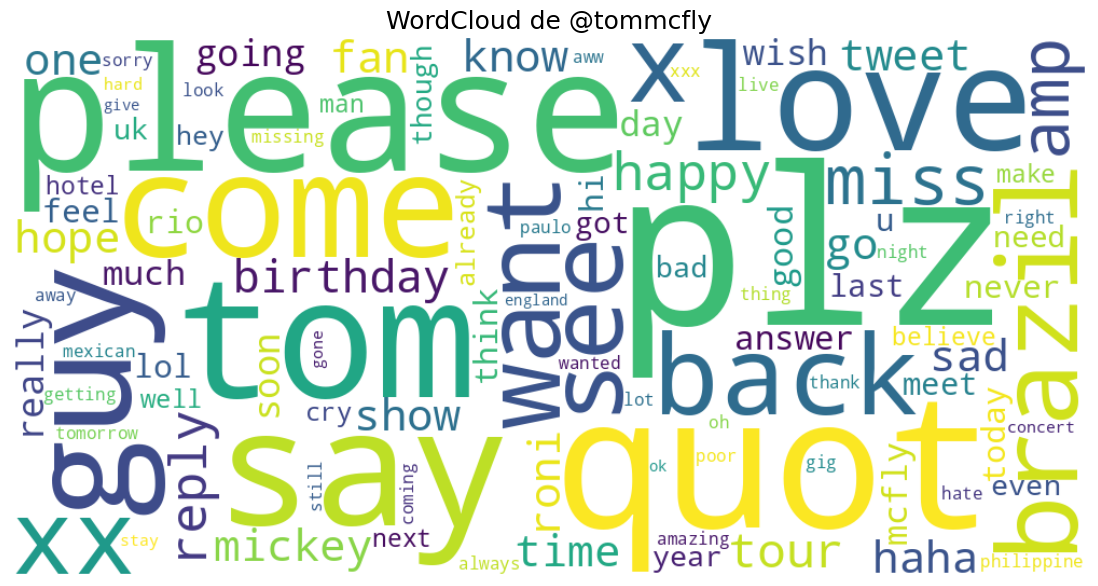

In [45]:
# Generamos la nube de palabras para @tommcfly
generar_wordcloud(corpus_usuario_1, '@tommcfly')

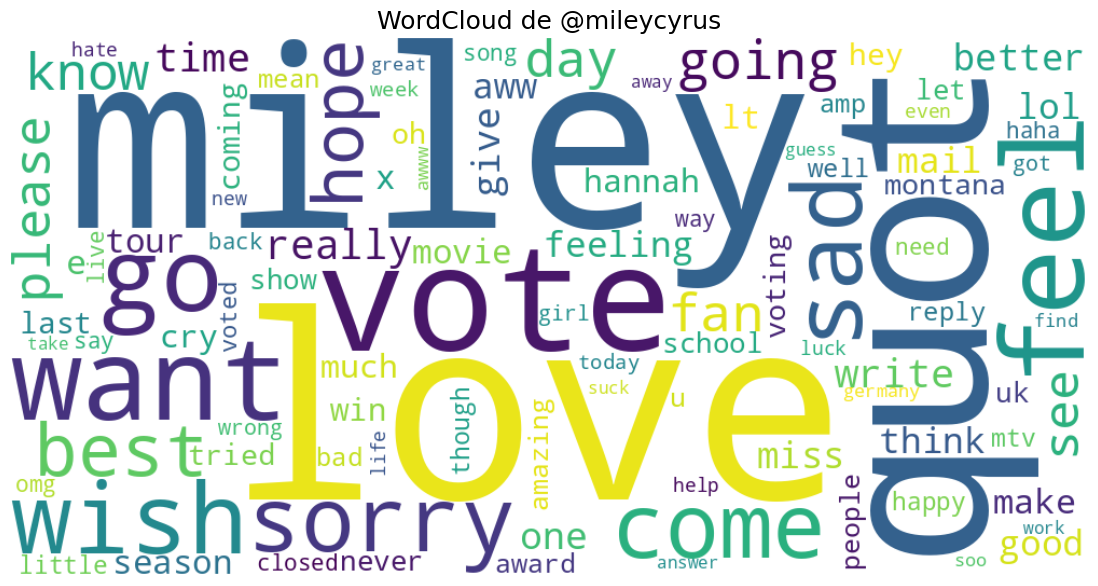

In [46]:
# Generamos la nube de palabras para @mileycyrus
generar_wordcloud(corpus_usuario_2, '@mileycyrus')

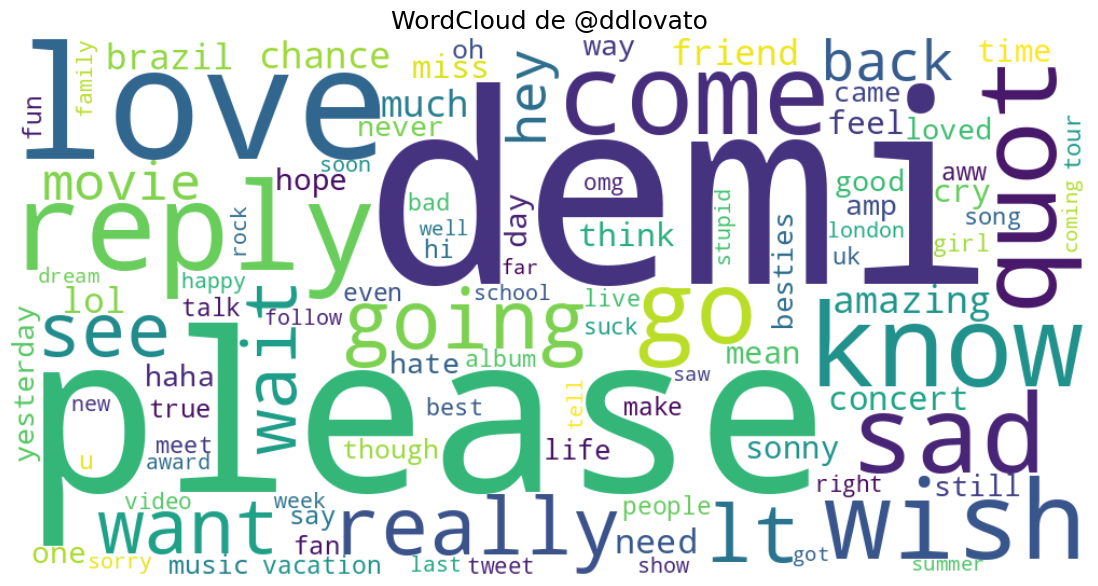

In [47]:
# Generamos la nube de palabras para @ddlovato
generar_wordcloud(corpus_usuario_3, '@ddlovato')

Las nubes de palabras permiten identificar visualmente los términos más frecuentes en los tweets relacionados con cada usuario.


**Identificar las palabras más frecuentes alrededor de cada mención**

In [48]:
from collections import Counter


def palabras_cercanas(corpus, usuario, ventana=5):


    palabras_contexto = []

    # Recorremos los tweets del corpus
    for tweet in corpus['content'].dropna():

        # Separamos el tweet en palabras
        palabras = str(tweet).split()

        # Buscamos la mención del usuario
        for indice, palabra in enumerate(palabras):

            if re.search(
                rf'@{re.escape(usuario)}\b',
                palabra,
                flags=re.IGNORECASE
            ):

                # Definimos el rango de palabras cercanas
                inicio = max(0, indice - ventana)
                fin = min(len(palabras), indice + ventana + 1)

                contexto = palabras[inicio:fin]

                # Agregamos las palabras encontradas
                palabras_contexto.extend(contexto)

    return palabras_contexto

In [49]:
def limpiar_palabras_contexto(palabras):


    palabras_limpias = []

    for palabra in palabras:

        # Convertimos a minúsculas
        palabra = palabra.lower()

        # Eliminamos signos de puntuación
        palabra = re.sub(r'[^a-z]', '', palabra)

        # Excluimos palabras vacías y menciones
        if (
            palabra
            and palabra not in stop_words
            and not palabra.startswith('tommcfly')
            and not palabra.startswith('mileycyrus')
            and not palabra.startswith('ddlovato')
        ):
            palabras_limpias.append(palabra)

    return palabras_limpias

In [50]:
# Obtenemos las palabras cercanas a @tommcfly
contexto_tommcfly = palabras_cercanas(
    corpus_usuario_1,
    usuario_1,
    ventana=5
)

# Obtenemos las palabras cercanas a @mileycyrus
contexto_mileycyrus = palabras_cercanas(
    corpus_usuario_2,
    usuario_2,
    ventana=5
)

# Obtenemos las palabras cercanas a @ddlovato
contexto_ddlovato = palabras_cercanas(
    corpus_usuario_3,
    usuario_3,
    ventana=5
)

# Limpiamos las palabras de cada contexto
contexto_tommcfly_limpio = limpiar_palabras_contexto(
    contexto_tommcfly
)

contexto_mileycyrus_limpio = limpiar_palabras_contexto(
    contexto_mileycyrus
)

contexto_ddlovato_limpio = limpiar_palabras_contexto(
    contexto_ddlovato
)

In [51]:
# Contamos las palabras más frecuentes de cada contexto
frecuencias_contexto = {
    '@tommcfly': Counter(contexto_tommcfly_limpio).most_common(20),
    '@mileycyrus': Counter(contexto_mileycyrus_limpio).most_common(20),
    '@ddlovato': Counter(contexto_ddlovato_limpio).most_common(20)
}

# Mostramos los resultados
for usuario, palabras in frecuencias_contexto.items():

    print(f'\nPalabras cercanas a {usuario}:')

    for palabra, frecuencia in palabras:
        print(f'{palabra}: {frecuencia}')


Palabras cercanas a @tommcfly:
tom: 93
say: 72
im: 50
plz: 49
quothappy: 48
birthday: 48
miss: 39
dont: 36
u: 31
cant: 28
please: 27
guys: 26
reply: 22
wish: 21
hey: 20
love: 20
come: 20
tour: 20
good: 19
want: 19

Palabras cercanas a @mileycyrus:
miley: 87
love: 66
im: 61
dont: 50
u: 46
feel: 41
wish: 38
best: 31
come: 28
vote: 28
sorry: 27
quotmileycyrusquotyou: 27
aww: 26
sad: 25
cant: 23
hope: 21
hey: 21
could: 21
whats: 21
go: 19

Palabras cercanas a @ddlovato:
demi: 68
im: 29
u: 26
wish: 24
hey: 23
dont: 21
please: 18
love: 18
know: 17
sad: 16
reply: 14
quotsonny: 14
chancequot: 14
cant: 13
yesterday: 13
come: 12
hope: 12
besties: 11
hate: 10
really: 10


In [52]:
# Convertimos los resultados en una tabla
tabla_frecuencias_contexto = pd.DataFrame({
    usuario: dict(palabras)
    for usuario, palabras in frecuencias_contexto.items()
}).fillna(0).astype(int)

# Mostramos la tabla ordenada
display(tabla_frecuencias_contexto)

,@tommcfly,@mileycyrus,@ddlovato
tom,93,0,0
say,72,0,0
im,50,61,29
plz,49,0,0
quothappy,48,0,0
birthday,48,0,0
miss,39,0,0
dont,36,50,21
u,31,46,26
cant,28,23,13


**Interpretar los motivos de las menciones**

In [53]:
# Creamos una tabla resumen con los principales patrones encontrados
resumen_menciones = pd.DataFrame({
    'Usuario': [
        '@tommcfly',
        '@mileycyrus',
        '@ddlovato'
    ],
    'Palabras destacadas': [
        'tom, say, plz, birthday, miss, reply, tour, love',
        'miley, love, feel, best, vote, sorry, wish, sad',
        'demi, please, reply, wish, sad, hope, hate, besties'
    ],
    'Posibles motivos de las menciones': [
        'Solicitar respuestas, expresar cariño, felicitarlo y comentar sobre giras.',
        'Expresar admiración, emociones, buenos deseos y solicitudes de apoyo o votación.',
        'Expresar cariño, solicitar respuestas y compartir emociones o comentarios personales.'
    ]
})

display(resumen_menciones)

,Usuario,Palabras destacadas,Posibles motivos de las menciones
0,@tommcfly,"tom, say, plz, birthday, miss, reply, tour, love","Solicitar respuestas, expresar cariño, felicit..."
1,@mileycyrus,"miley, love, feel, best, vote, sorry, wish, sad","Expresar admiración, emociones, buenos deseos ..."
2,@ddlovato,"demi, please, reply, wish, sad, hope, hate, be...","Expresar cariño, solicitar respuestas y compar..."


**Conclusiones del Problema 1**
\
\
## Conclusiones

1. Se identificaron los tres usuarios más mencionados dentro del conjunto de tweets: @tommcfly, @mileycyrus y @ddlovato.

2. Se construyó un corpus independiente para cada usuario, incluyendo el contenido del tweet, el identificador, la fecha y hora, y la longitud del texto.

3. Las nubes de palabras permitieron visualizar los términos más frecuentes asociados con cada usuario.

4. La combinación de las WordCloud y el análisis de palabras cercanas permitió obtener una interpretación más completa que utilizando únicamente la frecuencia general de las palabras.

7. Una limitación encontrada fue el uso de abreviaciones, lenguaje informal y residuos de formato propios de Twitter, como `im`, `plz` y expresiones con `quot`.